In [39]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from multiprocessing import Pool
from concurrent.futures import ProcessPoolExecutor
import concurrent.futures
import pandas as pd
from tqdm import tqdm
from scipy.optimize import minimize, basinhopping

plt.rcParams['text.latex.preamble'] = r"\usepackage{amsmath}"
plt.rc('font',**{'family':'sans-serif','sans-serif':['Helvetica']})
plt.rc('text',usetex=True)

import julia
from julia import Main
from julia import Distributed
Main.eval("using QuadGK")

In [40]:
Main.eval('using Distributed')
Main.eval('addprocs(4)') 

array([6, 7, 8, 9], dtype=int64)

In [41]:
Main.eval("""
    @everywhere begin
        using Distributed
        using DelimitedFiles      
        df_LO = readdlm("fixed order/EECLO.csv", ',')
        df_NLO = readdlm("fixed order/EECNLO.csv", ',')
        df_NNLO = readdlm("fixed order/EECNNLO.csv", ',')
    end
""")

Main.include("strong coupling\\constants.jl")
Main.include("strong coupling\\alpha_s.jl")

Main.include("fixed order\\perturbative EEC.jl")
Main.include("fixed order\\SCET.jl")
Main.include("fixed order\\non-singular.jl")
Main.include("fixed order\\analytic.jl")

Main.include("Σb.jl")
Main.include("cross section.jl")
Main.include("NP.jl")
Main.include("parallel/fit.jl")

<PyCall.jlwrap model>

In [46]:
χ_lower = 0.2
χ_upper = 70
χ_low = χ_lower
χ_up = χ_upper

In [47]:
optimal_params = [0.118, 0.866, 2.67, 1.13]

In [49]:
cut_list = {}
cut_list["sqrtz"] = [0,1/2]

In [50]:
error_type = "both"

df_NNLO = pd.read_csv("fixed order/EECNNLO.csv",header=None)

def fixed_error_func(angle: float, df: pd.DataFrame) -> float:
    angles = df.iloc[:, 0]      
    errors = df.iloc[:, 2]       
    
    pos = np.abs(angles.values - angle).argmin()
    return float(errors.iloc[pos])

In [51]:
#-------------------------------------------------------------------
dataset_names = ["SLD","TOPAZ_595","TOPAZ_533",
                "TASSO_435","TASSO_348","MARKII","MAC"]
#-------------------------------------------------------------------

df_original = {}

for name in dataset_names:
    file_path = f"data/{name}.csv"
    df0 = pd.read_csv(file_path)
    
    χ = df0["CHI"]
    EEC = df0["EEC"]
    ERROR = df0["ERROR"]
    Q = df0["Q"]
    BinSize = df0["BinSize"]

    print(Q[0])

    if error_type == "both":
        
        αs = Main.alpha_s_func(μf=Q[0], μi=91.1876, αs=0.118, order=4, nf=5)
        a = αs/(2*np.pi)

        fixed_error=[]
        for angle in χ:
            value = (a**3)*fixed_error_func(angle=angle, df=df_NNLO)
            fixed_error.append(value)
        ERROR = np.sqrt(df0["ERROR"]**2 + np.array(fixed_error)**2)
    
    df1 = pd.DataFrame({"CHI": χ, "EEC": EEC, "ERROR": ERROR, "Q": Q, "BinSize": BinSize})
    df_original[name] = df1

91.2
59.5
53.3
43.5
34.8
29.0
29.0


In [52]:
cut_list = {}
cut_list["sqrtz"] = [0,1/2]

In [53]:
df_truncated = {}

χ = {}
EEC = {}
ERROR = {}
Q = {}
BinSize = {}

df = df_original
for name in dataset_names:
    sqrtz_list = np.sqrt((1-np.cos(df[name]["CHI"]*np.pi/180))/2)
    kt_list = sqrtz_list*df[name]["Q"]

    if "sqrtz" in cut_list:
        sqrtz_lower, sqrtz_upper = cut_list["sqrtz"]
        df_truncated[name] = df[name][(sqrtz_list <= sqrtz_upper) & (sqrtz_list >= sqrtz_lower)]

    if "kt" in cut_list:
        χ_lower, χ_upper = cut_list["kt"]
        df_truncated[name] = df[name][(kt_list <= kt_upper) & (kt_list >= kt_lower)]

    if "χ" in cut_list:
        kt_lower, kt_upper = cut_list["kt"]
        df_truncated[name] = df[name][(df[name]["CHI"] <= χ_upper) & (df[name]["CHI"] >= χ_lower)]
    
    χ[name] = np.array(df_truncated[name]["CHI"])
    EEC[name] = np.array(df_truncated[name]["EEC"])
    ERROR[name] = np.array(df_truncated[name]["ERROR"])
    Q[name] = np.array(df_truncated[name]["Q"])
    BinSize[name] = np.array(df_truncated[name]["BinSize"])

#display(df_truncated)
for name in dataset_names:
    display(len(df_truncated[name]))

16

16

16

16

16

16

16

In [54]:
def DELTA_func(ylist,PRED):
    l = len(ylist)
    theory = np.zeros(l)
    for i in range(l):
        simpson = 1/12*(PRED[0][i] + 4*PRED[1][i] + 2*PRED[2][i] + 4*PRED[3][i] + PRED[4][i])
        theory[i] = np.nan_to_num(simpson,nan=0.0)
    return theory - ylist

def CHI2_func(DELTA,ERROR):
    chi_squared = np.sum(np.square(DELTA/ERROR))
    return chi_squared

In [55]:
def objective(params, df):

    #----------
    XLL = 2 #1 for NLL
    #----------

    N = 5
    
    chi2 = 0
    N_total = 0
    
    αs = params[0]
    params_noαs = params[1:]

    dataset_names = df.keys()

    for name in dataset_names:
        xlist={}
        xlist_mid = np.array(df[name]["CHI"])
        binsize = np.array(df[name]["BinSize"]) 
        for i in range(N):
            xlist[i]=xlist_mid-binsize/2+i*binsize/(N-1)

        ylist=np.array(df[name]["EEC"])
        ERROR_list=np.array(df[name]["ERROR"])

        data_size = len(xlist_mid)
        N_total = N_total + data_size

        PRED={}

        parameters = params_noαs
        for quartile in range(N):
            PRED[quartile] = Main.model(xlist=xlist[quartile], αs=αs, Qlist=np.array(df[name]["Q"]), order=XLL, params=parameters)                
        DELTA =  DELTA_func(ylist,PRED)                       

        chi_square = CHI2_func(DELTA,ERROR_list)
        chi2 = chi2 + chi_square

    return chi2/N_total

In [56]:
Q_list = {}
Q_list["SLD"]       = 91.2
Q_list["OPAL"]      = 91.2
Q_list["DELPHI"]    = 91.2
Q_list["TOPAZ_595"] = 59.5
Q_list["TOPAZ_533"] = 53.3
Q_list["TASSO_435"] = 43.5
Q_list["TASSO_348"] = 34.8
Q_list["MARKII"]    = 29.0
Q_list["MAC"]       = 29.0

Test

In [57]:
objective(optimal_params, df_truncated)

1.60612565280544

Import replicas 

In [58]:
result_set = {}
accuracies = ["fit_1","scan_1"]
for XLL in accuracies:
    result_set[XLL] = pd.read_csv("result/"+XLL+".csv")

In [59]:
import ast
def convert_to_list(string):
    corrected_string = string.replace("      ", ",")
    corrected_string = corrected_string.replace("     ", ",")
    corrected_string = corrected_string.replace("    ", ",") 
    corrected_string = corrected_string.replace("   ", ",") 
    corrected_string = corrected_string.replace("  ", ",")    
    corrected_string = corrected_string.replace(" ", ",")
    l=len(corrected_string)
    new_string=""
    for i in range(1,l-1):
        if (corrected_string[i]=="," and (corrected_string[i-1]=="[" or corrected_string[i+1]=="]")):
            new_string = new_string
        else:
            new_string = new_string + corrected_string[i]

    new_string = new_string + "]"
    new_string = "[" + new_string

    return ast.literal_eval(new_string)

αs_set = {}
Ω1_set = {}
a_set = {}

for XLL in accuracies:
    results_df = result_set[XLL]
    αs_set[XLL] = results_df['αs'].to_numpy()
    params = results_df['params'].apply(convert_to_list)
    params = np.array(params.to_list())

    rows = len(params)
    cols = len(params[0])
    a_list = {}

    for i in range(cols):
        a_list[i] = params[:,i]
            
    a_set[XLL] = a_list

    #print(a_list)

In [60]:
#print(N_params)
#print(N_replicas)
params_replicas={}
for XLL in accuracies:
    N_params = len(a_set[XLL])
    N_replicas = len(a_set[XLL][0])
    params_reps = []
    for i in range(N_replicas):
        params = []
        for j in range(N_params):
            value = a_set[XLL][j][i]
            params.append(value)
        params_reps.append(params)
    params_replicas[XLL]=params_reps

In [61]:
display(params_replicas)
#display(αs_set)

{'fit_1': [[0.85778, 2.68023, 1.13489],
  [0.86256, 2.65811, 1.13273],
  [0.86373, 2.63739, 1.11919],
  [0.86302, 2.69976, 1.13139],
  [0.86211, 2.67733, 1.12034],
  [0.85872, 2.61721, 1.11617],
  [0.86282, 2.63855, 1.11344],
  [0.86153, 2.69006, 1.13045],
  [0.86033, 2.73483, 1.1325],
  [0.86972, 2.60627, 1.09888],
  [0.86672, 2.6407, 1.12102],
  [0.86212, 2.64973, 1.12702],
  [0.86381, 2.65299, 1.12968],
  [0.86449, 2.63639, 1.11941],
  [0.85682, 2.74264, 1.14194],
  [0.86505, 2.66538, 1.1264],
  [0.86123, 2.66589, 1.1182],
  [0.86304, 2.72001, 1.12646],
  [0.8578, 2.67956, 1.13257],
  [0.85966, 2.69371, 1.12574],
  [0.85865, 2.67602, 1.11794],
  [0.85972, 2.66104, 1.1143],
  [0.86041, 2.66924, 1.1275],
  [0.86146, 2.6638, 1.13007],
  [0.85897, 2.67825, 1.13157],
  [0.86524, 2.6226, 1.11338],
  [0.86724, 2.60045, 1.119],
  [0.85839, 2.65866, 1.117],
  [0.86562, 2.63682, 1.10511],
  [0.85639, 2.67272, 1.13164],
  [0.85787, 2.6753, 1.11513],
  [0.85905, 2.66697, 1.11943],
  [0.85267, 2

Calculate bands

In [62]:
N_points=200
xlist = np.linspace(χ_low, χ_up, N_points, endpoint=True)
length=len(xlist)

EEC_replicas = {}
for XLL in accuracies:
    i=0
    EEC_reps = []
    for params in tqdm(params_replicas[XLL]):
        #print(params) 
        EEC = {}
        for name in dataset_names:       
            Qlist = Q_list[name]*np.ones(N_points)
            EEC[name] = Main.model(Qlist=Qlist, xlist=xlist, αs=αs_set[XLL][i], order=2, params=params)  

        EEC_reps.append(EEC)
        i = i+1
    EEC_replicas[XLL] = EEC_reps

100%|██████████| 200/200 [01:04<00:00,  3.12it/s]


In [63]:
EEC_replicas

{'fit_1': [{'SLD': array([0.17142487, 0.46368165, 0.7336414 , 0.97055456, 1.16771523,
          1.32258573, 1.43618528, 1.51207908, 1.55530198, 1.5714436 ,
          1.56599303, 1.54394296, 1.50960152, 1.46654552, 1.41765713,
          1.36520269, 1.31092662, 1.25613225, 1.20181396, 1.14865769,
          1.09714821, 1.04760698, 1.00023141, 0.95512559, 0.91232448,
          0.8718131 , 0.8335413 , 0.79743468, 0.76340266, 0.73134492,
          0.70115644, 0.67273087, 0.64596265, 0.62074368, 0.59698452,
          0.57458585, 0.55345825, 0.53351721, 0.5146834 , 0.49691616,
          0.4800466 , 0.4641106 , 0.44901495, 0.43470417, 0.42112699,
          0.40823592, 0.39786376, 0.38652591, 0.3756935 , 0.36518101,
          0.35507947, 0.34539587, 0.33610518, 0.3271841 , 0.31889451,
          0.31106621, 0.3035452 , 0.29631554, 0.28936107, 0.2825983 ,
          0.27602461, 0.26968678, 0.26356548, 0.25765456, 0.25209202,
          0.24692272, 0.24193135, 0.23710914, 0.23244779, 0.22782316,
    

In [25]:
Main.eval('rmprocs(workers())')

<PyCall.jlwrap Task (runnable) @0x0000022197abd180>

In [64]:
EEC_upper = {}
EEC_lower = {}

for XLL in accuracies:
    EEC_up = {}
    EEC_low = {}
    for name in dataset_names: 
        upper_band = []
        lower_band = []
        for i in range(length):
            compare_list = []
            for j in range(N_replicas):
                value = EEC_replicas[XLL][j][name][i]
                compare_list.append(value)
            upper_EEC = np.percentile(compare_list,84)
            upper_band.append(upper_EEC)
            lower_EEC =np.percentile(compare_list,16)
            lower_band.append(lower_EEC)
        EEC_up[name]=upper_band
        EEC_low[name]=lower_band    
    EEC_upper[XLL] = EEC_up
    EEC_lower[XLL] = EEC_low 

import json
with open("plot_data/fit_1_upper.json", "w") as file:
    json.dump(EEC_upper, file)
with open("plot_data/fit_1_lower.json", "w") as file:
    json.dump(EEC_lower, file)

In [65]:
import json
EEC_upper = {}
EEC_lower = {}

with open("plot_data/fit_1_upper.json", "r") as file:
    EEC_upper = json.load(file)
with open("plot_data/fit_1_lower.json", "r") as file:
    EEC_lower = json.load(file)

for XLL in accuracies:
    display(np.array(EEC_upper[XLL]["SLD"])-np.array(EEC_lower[XLL]["SLD"]))

array([0.00632106, 0.01631382, 0.02389786, 0.02871864, 0.03197456,
       0.03264457, 0.03002614, 0.02876465, 0.02689805, 0.02472557,
       0.02269007, 0.02147421, 0.01935644, 0.0175645 , 0.0164126 ,
       0.01561766, 0.01468012, 0.01439046, 0.01327081, 0.01267228,
       0.01188661, 0.01101867, 0.01033012, 0.0096999 , 0.00917855,
       0.00858026, 0.00789252, 0.00724007, 0.00670064, 0.00638712,
       0.00597211, 0.00553478, 0.00531646, 0.00496039, 0.00483058,
       0.00466913, 0.00446302, 0.00416498, 0.00394281, 0.00383852,
       0.00372303, 0.00362649, 0.00349615, 0.0034324 , 0.00339403,
       0.00334425, 0.00337139, 0.00331939, 0.00325088, 0.00323885,
       0.00320949, 0.00311639, 0.00309438, 0.00307723, 0.00298817,
       0.00291683, 0.00333394, 0.00283643, 0.00279028, 0.00273576,
       0.00271885, 0.00270152, 0.00265736, 0.00259528, 0.00257372,
       0.00254328, 0.0024785 , 0.00241919, 0.00237543, 0.00233915,
       0.00232698, 0.002307  , 0.00227822, 0.00224475, 0.00221

array([0.02539023, 0.06759761, 0.10376545, 0.1306471 , 0.14709096,
       0.15318211, 0.15108767, 0.14244563, 0.12957319, 0.11515375,
       0.1002724 , 0.0861606 , 0.07358915, 0.06060921, 0.05088754,
       0.0418585 , 0.03415586, 0.02881348, 0.02406573, 0.02088002,
       0.01880924, 0.01857777, 0.0169526 , 0.01630518, 0.01616425,
       0.01655222, 0.01672625, 0.01684029, 0.01717984, 0.01737136,
       0.01725218, 0.01692115, 0.01687404, 0.01662804, 0.01649686,
       0.01632817, 0.01615229, 0.01581711, 0.01552388, 0.01522991,
       0.01491331, 0.01457929, 0.0142149 , 0.01379914, 0.01339001,
       0.01304927, 0.01271432, 0.01237602, 0.01201354, 0.01164856,
       0.0112973 , 0.01095959, 0.01063499, 0.01034611, 0.01005205,
       0.00977044, 0.00977992, 0.00923487, 0.0089802 , 0.00873913,
       0.00850155, 0.00827302, 0.00805125, 0.00784643, 0.00764757,
       0.00745583, 0.00726828, 0.00709252, 0.00691946, 0.00674841,
       0.00657288, 0.00643035, 0.00627882, 0.00613197, 0.00598

Central Curve

In [66]:
N_points=200
xlist = np.linspace(χ_low, χ_up, N_points, endpoint=True)
length=len(xlist)

αs=optimal_params[0]
params_noαs = optimal_params[1:]

central={}

for name in dataset_names:       
    Qlist = Q_list[name]*np.ones(N_points)
    central[name] = Main.model(Qlist=Qlist, xlist=xlist, αs=αs, order=2, params=params_noαs)  

In [67]:
display(central)

{'SLD': array([0.17357855, 0.4694036 , 0.74239652, 0.98160641, 1.18027175,
        1.3359235 , 1.44972548, 1.52541223, 1.56817484, 1.58389517,
        1.57764289, 1.55497031, 1.52004616, 1.47645988, 1.4270962 ,
        1.37421835, 1.31956512, 1.26443335, 1.20981146, 1.15637966,
        1.10461787, 1.05484353, 1.00725086, 0.96194134, 0.91894782,
        0.87825365, 0.83980744, 0.80353382, 0.7693414 , 0.73712923,
        0.7067918 , 0.67822242, 0.65131523, 0.6259618 , 0.60207254,
        0.57954795, 0.55829847, 0.53823944, 0.51929135, 0.50141375,
        0.48443673, 0.468397  , 0.45320092, 0.43879286, 0.42512149,
        0.41213924, 0.4016788 , 0.39025543, 0.37934019, 0.36874749,
        0.3585683 , 0.34880945, 0.33944585, 0.3304541 , 0.32209605,
        0.31420143, 0.3066161 , 0.29932405, 0.29230909, 0.28548767,
        0.27885706, 0.27246402, 0.26628908, 0.26032614, 0.25471309,
        0.24949473, 0.24445568, 0.23958715, 0.23488081, 0.23021244,
        0.22542616, 0.22074189, 0.2162097

Calculate data

In [68]:
αs=optimal_params[0]
params_noαs = optimal_params[1:]
#print(params_noαs)

v={}
non_singular = {}
central_data={}

for name in dataset_names:

    x_array = np.array(df[name]["CHI"])
    Q_array = np.array(df[name]["Q"])
    central_data[name] = Main.model(Qlist=Q_array, xlist=x_array, αs=αs, order=2, params=params_noαs)  

In [69]:
display(central_data["SLD"])

array([1.38363170e+00, 8.74748648e-01, 5.71917834e-01, 4.04465247e-01,
       3.07513086e-01, 2.43747920e-01, 2.00098774e-01, 1.69754598e-01,
       1.47151651e-01, 1.29868729e-01, 1.16377074e-01, 1.07118223e-01,
       9.75733452e-02, 9.14725886e-02, 8.57208245e-02, 8.12879335e-02,
       7.77980673e-02, 7.51084159e-02, 7.25380371e-02, 7.18937058e-02,
       7.01923524e-02, 6.98863620e-02, 6.87580983e-02, 6.95743003e-02,
       7.03625538e-02, 7.10100299e-02, 7.30860800e-02, 7.50264888e-02,
       7.83605446e-02, 8.09266206e-02, 8.46584453e-02, 9.12562492e-02,
       9.56900262e-02, 1.03955719e-01, 1.13032143e-01, 1.23776532e-01,
       1.35956172e-01, 1.54423457e-01, 1.75730865e-01, 2.05250562e-01,
       2.39918964e-01, 2.88992902e-01, 3.57670526e-01, 4.50270690e-01,
       6.00095728e-01, 8.16180959e-01, 1.20353786e+00, 1.86959702e+00,
       9.63593791e+01])

In [70]:
accuracy = ["fit_1","scan_1"]

df_fitted={}
central_fitted={}
for name in dataset_names:
    df_fitted[name] = df[name][(df[name]["CHI"] >= χ_lower) & (df[name]["CHI"] <= χ_upper)]
    central_fitted[name] = central_data[name][0:18]

#df_fitted["OPAL_new"] = df["OPAL_new"][(df["OPAL_new"]["CHI"] >= χ_lower) & (df["OPAL_new"]["CHI"] <= χ_upper)]
#central_fitted["OPAL_new"] = central_data["OPAL_new"][30:60]

name_set = {}
name_set["SLD"]       = "SLD"
name_set["OPAL"]      = "OPAL_old"
name_set["OPAL_new"]  = "OPAL"
name_set["DELPHI"]    = "DELPHI"
name_set["TOPAZ_595"] = "TOPAZ"
name_set["TOPAZ_533"] = "TOPAZ"
name_set["TASSO_435"] = "TASSO"
name_set["TASSO_348"] = "TASSO"
name_set["MARKII"]    = "MARKII"
name_set["MAC"]       = "MAC"

In [71]:
df_fitted

{'SLD':      CHI     EEC     ERROR     Q  BinSize
 0    5.4  1.3160  0.032808  91.2      3.6
 1    9.0  0.8740  0.020608  91.2      3.6
 2   12.6  0.5980  0.019352  91.2      3.6
 3   16.2  0.4250  0.011290  91.2      3.6
 4   19.8  0.3100  0.014205  91.2      3.6
 5   23.4  0.2410  0.005242  91.2      3.6
 6   27.0  0.1990  0.005225  91.2      3.6
 7   30.6  0.1680  0.006162  91.2      3.6
 8   34.2  0.1460  0.005189  91.2      3.6
 9   37.8  0.1280  0.004224  91.2      3.6
 10  41.4  0.1180  0.003275  91.2      3.6
 11  45.0  0.1099  0.002845  91.2      3.6
 12  48.6  0.1014  0.003330  91.2      3.6
 13  52.2  0.0935  0.002915  91.2      3.6
 14  55.8  0.0901  0.002406  91.2      3.6
 15  59.4  0.0867  0.002547  91.2      3.6
 16  63.0  0.0827  0.002580  91.2      3.6
 17  66.6  0.0802  0.002182  91.2      3.6,
 'TOPAZ_595':      CHI    EEC     ERROR     Q  BinSize
 0    5.4  1.037  0.049740  59.5      3.6
 1    9.0  0.850  0.038184  59.5      3.6
 2   12.6  0.654  0.031306  59.5    

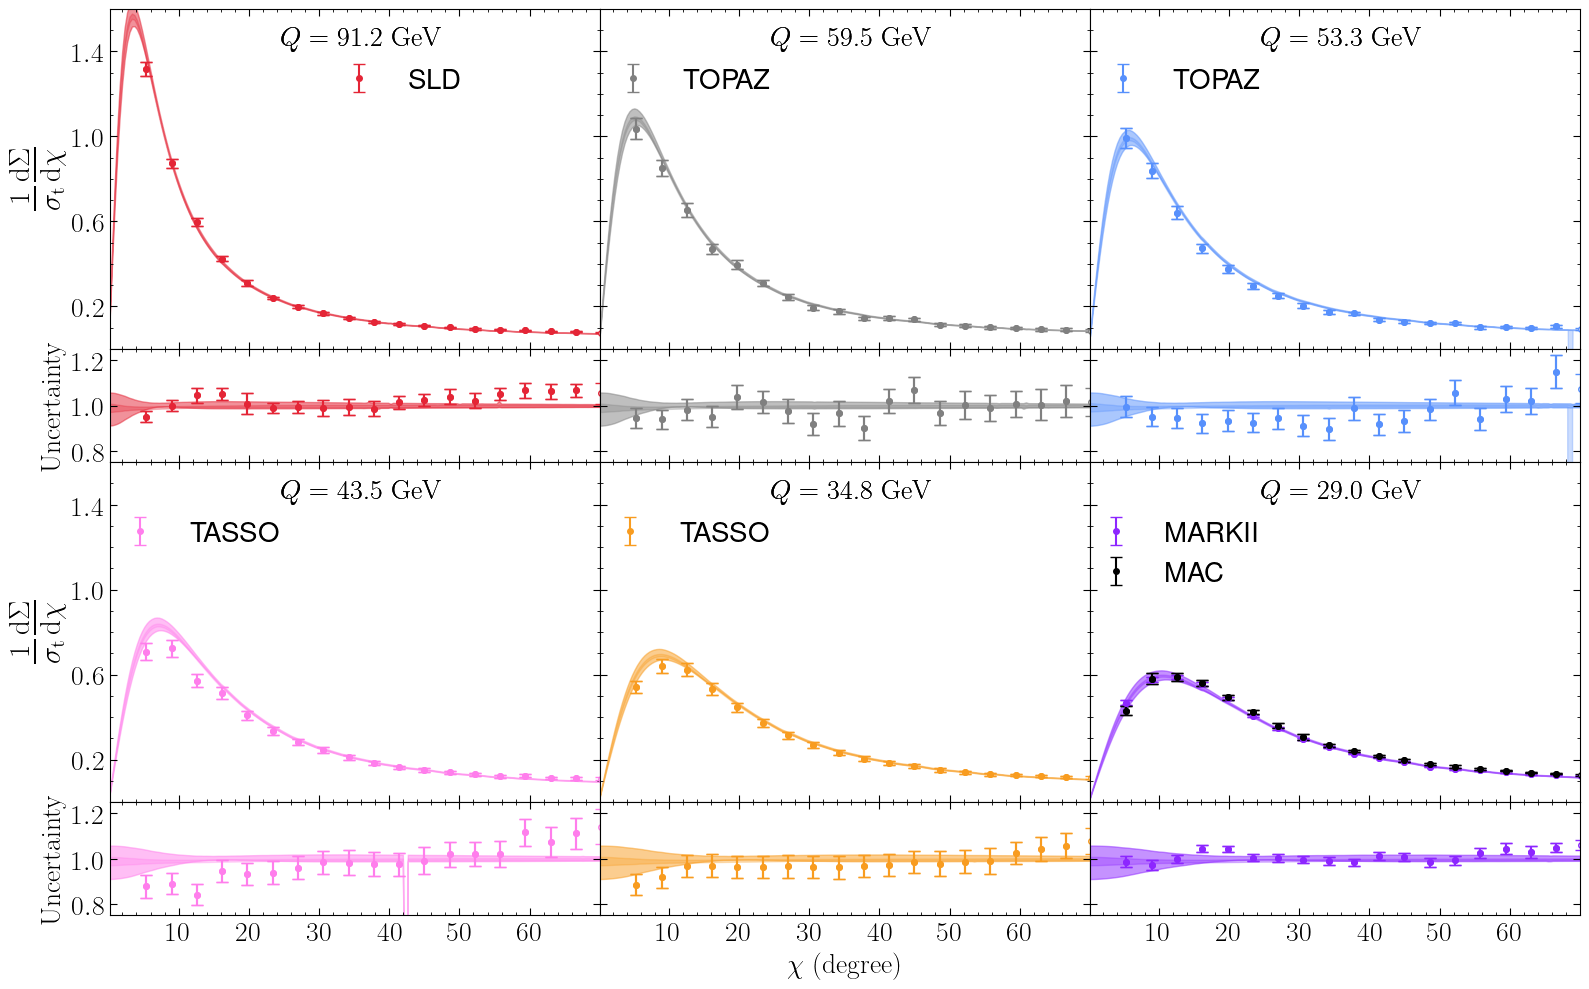

In [72]:
fig, axes = plt.subplots(4, 3, figsize=(16, 10), sharex='col', gridspec_kw={'height_ratios': [3, 1, 3, 1]})
ax1, ax2, ax3, ax4, ax5, ax6, ax7, ax8, ax9, ax10, ax11, ax12 = axes.ravel()

#Settings-----------------------------------------------------------------
sizeOfFont= 20
sizeOfTick = 20
sizeOfCap = 4
sizeOfMark = 4

props = dict(boxstyle='round', facecolor='white', alpha=0)

#color = ["blue","green","blue","green","blue","green","blue"]
#color = ["red","orange","gray","teal","blue","purple","black"]

blue=(87/255,144/255,252/255)
orange=(248/255,156/255,32/255)
red=(228/255,37/255,54/255)
purple1=(150/150,74/150,139/150)
gray=(156/161,156/161,161/161)
purple2=(122/221,33/221,221/221)
color = [red,"gray",blue,purple1,orange,purple2,"black"]

transparency=[0.3,0.5]

ax_list = [ax1,ax2,ax3,ax7,ax8,ax9]
ax_ratios = [ax4,ax5,ax6,ax10,ax11,ax12]

Q_set = [91.2,59.5,53.3,43.5,34.8,29.0]
#names_band=["SLD","TOPAZ_595","TOPAZ_533","TASSO_435","TASSO_348","MARKII","MAC"]
names_band=["SLD","TOPAZ_595","TOPAZ_533","TASSO_435","TASSO_348","MARKII"]
#--------------------------------------------------------------------------

#--------------------------------------------------------------------------------------------------------------------------------------------------------------------
i=0
j=0
for Q in Q_set:
    for name in dataset_names:
        if Q_list[name]==Q:
            ax_list[i].errorbar(df[name]["CHI"], df[name]["EEC"], df[name]["ERROR"], fmt='o', color=color[j], capsize=sizeOfCap, markersize=sizeOfMark, mfc='w')
            ax_list[i].errorbar(df_fitted[name]["CHI"], df_fitted[name]["EEC"], df_fitted[name]["ERROR"], fmt='o', color=color[j], capsize=sizeOfCap,markersize=sizeOfMark,label=str(name_set[name]))
            j=j+1
    i=i+1

j=0
for XLL in accuracy:
    i=0
    for Q in Q_set:
        for name in names_band:
            if Q_list[name]==Q:
                ax_list[i].fill_between(xlist, EEC_upper[XLL][name], EEC_lower[XLL][name], alpha=transparency[j], color=color[i])
                ax_list[i].text(0.35, 0.95, r"\rm $Q = \ $" + str(Q_list[name]) + " GeV", transform=ax_list[i].transAxes, fontsize=sizeOfFont, verticalalignment='top', bbox=props)
                #ax_list[i].plot(xlist*180/np.pi, EEC_upper[XLL][name], color=color[i], linewidth=1)
                #ax_list[i].plot(xlist*180/np.pi, EEC_lower[XLL][name], color=color[i], linewidth=1)
        i=i+1
    j=j+1

for ax in ax_list:
    ax.minorticks_on()
    ax.tick_params(axis="both",direction="in", length=5,labelsize = sizeOfTick, top=True, right=True)
    ax.tick_params(axis="both",which = "minor",direction="in", length=2.5,labelsize = sizeOfTick, top=True, right=True)
    ax.legend(frameon = False,fontsize = sizeOfTick, bbox_to_anchor=(0.4, 0.9))
    ax.set_xlim(χ_low,χ_up)
    ax.set_xticks([10,20,30,40,50,60])
    ax.set_ylim(0.0,1.6)
    ax.set_yticks([0.2,0.6,1.0,1.4])

ax2.set_yticklabels([])
ax3.set_yticklabels([])
ax8.set_yticklabels([])
ax9.set_yticklabels([])

ax1.set_ylabel(r"\rm $\frac{1}{\sigma_{\rm{t}}} \frac{\rm{d} \Sigma}{\rm{d} \chi}$",fontsize=1.5*sizeOfFont)
ax7.set_ylabel(r"\rm $\frac{1}{\sigma_{\rm{t}}} \frac{\rm{d} \Sigma}{\rm{d} \chi}$",fontsize=1.5*sizeOfFont)
#--------------------------------------------------------------------------------------------------------------------------------------------------------------------

#--------------------------------------------------------------------------------------------------------------------------------------------------------------------
j=0
for XLL in accuracy:
    i=0
    for Q in Q_set:
        for name in names_band:
            if Q_list[name]==Q:
                ax_ratios[i].fill_between(xlist, EEC_upper[XLL][name]/central[name], EEC_lower[XLL][name]/central[name], alpha=transparency[j], color=color[i])
                #ax_ratios[i].plot(xlist*180/np.pi, EEC_upper[XLL][name]/central[name], color=color[i], linewidth=1)
                #ax_ratios[i].plot(xlist*180/np.pi, EEC_lower[XLL][name]/central[name], color=color[i], linewidth=1)
        i=i+1
    j=j+1

i=0
j=0
for Q in Q_set:
    for name in names_band:
        if Q_list[name]==Q:
            ax_ratios[i].errorbar(df[name]["CHI"], df[name]["EEC"]/central_data[name], df[name]["ERROR"]/central_data[name], fmt='o', color=color[j], capsize=sizeOfCap, markersize=sizeOfMark, mfc='w')
            ax_ratios[i].errorbar(df_fitted[name]["CHI"], df_fitted[name]["EEC"]/central_fitted[name], df_fitted[name]["ERROR"]/central_fitted[name], fmt='o', color=color[j], capsize=sizeOfCap, markersize=sizeOfMark)
            j=j+1
    i=i+1

for ax in ax_ratios:
    ax.tick_params(axis="both",direction="in", length=5,labelsize = sizeOfTick, top=True, right=True)
    ax.tick_params(axis="both",which = "minor",direction="in", length=2.5,labelsize = sizeOfTick, top=True, right=True)
    ax.set_xlim(χ_low,χ_up)
    ax.set_xticks([10,20,30,40,50,60])
    ax.set_ylim(0.75,1.25)
    ax.set_yticks([0.8,1.0,1.2])

ax5.set_yticklabels([])
ax6.set_yticklabels([])
ax11.set_yticklabels([])
ax12.set_yticklabels([])

ax4.set_ylabel(r"\rm $\rm{Uncertainty}$",fontsize=sizeOfFont)
ax10.set_ylabel(r"\rm $\rm{Uncertainty}$",fontsize=sizeOfFont)
ax11.set_xlabel(r"\rm $\chi \ (\rm{degree})$",fontsize=sizeOfFont)
#--------------------------------------------------------------------------------------------------------------------------------------------------------------------

plt.tight_layout()
plt.subplots_adjust(wspace=0,hspace=0)
plt.show()

fig.savefig('fit_bbstar.pdf')